In [ ]:
from google.colab import files
uploaded=files.upload()

Saving image 1.jpg to image 1 (1).jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)


Converting an image from spatial to frequency domain

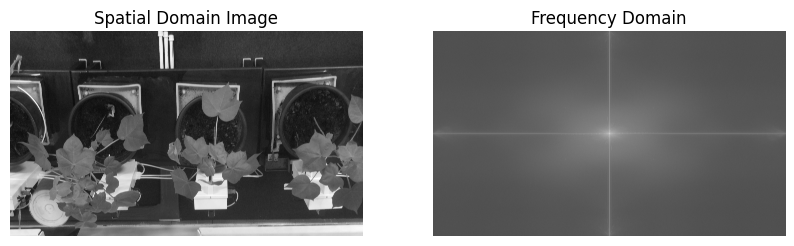

In [ ]:
f=np.fft.fft2(img)
fshift=np.fft.fftshift(f)
magnitude_spectrum = 20* np.log(np.abs(fshift)+1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Spatial Domain Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Domain")
plt.axis("off")

plt.show()


Low Pass Filter- reomving high frequency components

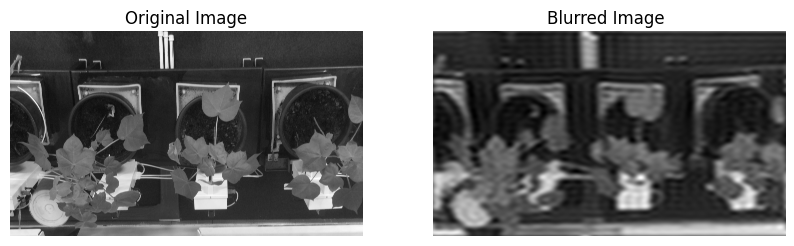

In [ ]:


rows, cols = img.shape
crow, ccol = rows//2, cols//2
mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1
fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_back, cmap='gray')
plt.title("Blurred Image ")
plt.axis("off")

plt.show()


High Pass Fitler -  removing low pass frequencies

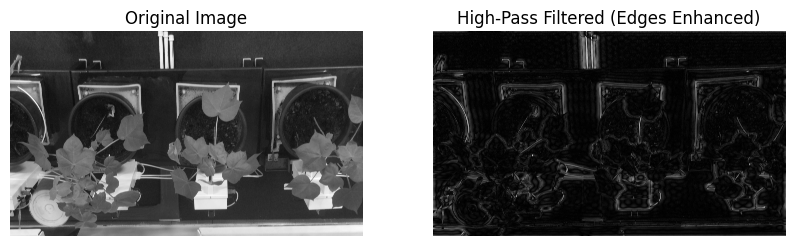

In [ ]:
mask = np.ones((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0
fshift_filtered = fshift * mask
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_back, cmap='gray')
plt.title("High-Pass Filtered ")
plt.axis("off")

plt.show()


So Frequency components control different image properties